In [27]:
%%capture
%run script_nettoyage.ipynb

Analyse 1

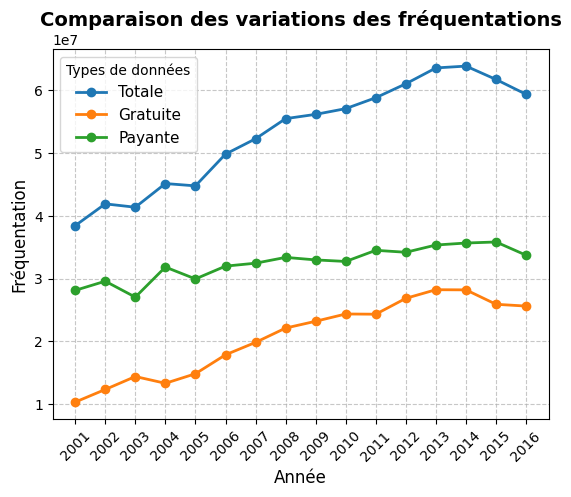

In [28]:
def tracer_comparaison_frequentation(bases_de_donnees, an = 'annee', freq = 'frequentation'):
    """
    Automatise la création de graphiques

    Parameters 
    ----------
    bases_de_donnees : dictionnaire 
    dictionnaire contenant en valeur les base de données

    an : int
    Pour que faire les manipulations panda nom de la colonne année

    an : int
    idem, ici c'est frequentation
    """
    # On parcourt notre dictionnaire pour tracer chaque courbe
    for nom_courbe, df in bases_de_donnees.items():
        
        # Pour les analyses descriptives on ne gadre que les musées ouverts
        df_propre = df[df['Statut'] == 'Ouvert']
        
        # On étudie la fréquentation totale, par an
        freq_annee = df_propre.groupby(an)[freq].sum()
        freq_annee.index = freq_annee.index.astype(int)
        
        # On trace la courbe
        plt.plot(freq_annee.index, freq_annee, marker='o', linewidth=2, label=nom_courbe)

    
    
    plt.title('Comparaison des variations des fréquentations', fontsize=14, fontweight='bold')
    plt.xlabel('Année', fontsize=12)
    plt.ylabel('Fréquentation', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # On affiche les année à 45°
    plt.xticks(freq_annee.index, rotation=45) 
    
    # la légende
    plt.legend(title='Types de données', fontsize=11)
    plt.show()


mes_donnees = {
    "Totale": df_freq_totale,
    "Gratuite": df_freq_gratuite,
    "Payante": df_freq_payante    
}

tracer_comparaison_frequentation(
    mes_donnees, 
    an='annee',           
    freq='frequentation'    
)

Création d'une base de donnée de la population par région en 2010.

In [29]:
pop_2010 = pd.DataFrame({
    "NOMREG": [
        "AUVERGNE-RHÔNE-ALPES",
        "BOURGOGNE-FRANCHE-COMTE",
        "BRETAGNE",
        "CENTRE-VAL DE LOIRE",
        "CORSE",
        "GRAND EST",
        "GUADELOUPE",
        "GUYANE",
        "HAUTS-DE-France",
        "ÎLE-DE-France",
        "LA REUNION",
        "MARTINIQUE",
        "NORMANDIE",
        "NOUVELLE-AQUITAINE",
        "OCCITANIE",
        "PAYS DE LA LOIRE",
        "PROVENCE-ALPES-CÔTE D'AZUR",
        "SAINT-PIERRE ET MIQUELON"
    ],
    "population_2010": [
        1347387 + 6230691,
        1642115 + 1171763,
        3199066,
        2548065,
        309693,
        1845687 + 2350920 + 1335923,
        403355,
        229040,
        4038157 + 1914844,
        11786234,
        821136,
        394173,
        1836954 + 1473494,
        3232352 + 1770363 + 742771,
        2881756 + 2636350,
        3571495,
        4899155,
        6081
    ]
})

df_freq_totale = df_freq_totale.merge(pop_2010, on="NOMREG", how="left")

df_freq_totale["freq_pour_1000_hab"] = (
    pd.to_numeric(df_freq_totale["frequentation"], errors="coerce")
    / df_freq_totale["population_2010"] * 1000
)

df_freq_totale

,REF DU MUSEE,NOMREG,NOM DU MUSEE,VILLE,Fréquentation,annee,frequentation,speciale,freq_net,Statut,population_2010,freq_pour_1000_hab
0,0105301,AUVERGNE-RHÔNE-ALPES,Musée du Brou,BOURG-EN-BRESSE,Totale,2001,74056,False,74056.0,Ouvert,7578078,9.772399
1,0105302,AUVERGNE-RHÔNE-ALPES,Musée Départemental des Pays De l'Ain,BOURG-EN-BRESSE,Totale,2001,NaN,True,NaN,NA,7578078,NaN
2,0106401,AUVERGNE-RHÔNE-ALPES,Musée de la Société d'Histoire et d'Archéologie,BRIORD,Totale,2001,100,False,100.0,Ouvert,7578078,0.013196
3,0113701,AUVERGNE-RHÔNE-ALPES,Musée Départemental du Revermont,TREFFORT-CUISIAT,Totale,2001,22234,False,22234.0,Ouvert,7578078,2.933989
4,0119201,AUVERGNE-RHÔNE-ALPES,Musée Archéologique,IZERNORE,Totale,2001,204,False,204.0,Ouvert,7578078,0.026920
...,...,...,...,...,...,...,...,...,...,...,...,...
19851,8413701,PROVENCE-ALPES-CÔTE D'AZUR,Musée Archéologique Théo Desplans,VAISON-LA-ROMAINE,Totale,2016,76154,False,76154.0,Ouvert,4899155,15.544313
19852,8413801,PROVENCE-ALPES-CÔTE D'AZUR,Musée Départemental du Cartonnage et de l'Impr...,VALREAS,Totale,2016,NC,True,NaN,NA,4899155,NaN
19853,8413901,PROVENCE-ALPES-CÔTE D'AZUR,Musée-Bibliothèque François Pétrarque,FONTAINE-DE-VAUCLUSE,Totale,2016,2118,False,2118.0,Ouvert,4899155,0.432319
19854,8413902,PROVENCE-ALPES-CÔTE D'AZUR,Musée Jean Garcin 39-45 : L'appel de la Liberté,FONTAINE-DE-VAUCLUSE,Totale,2016,7718,False,7718.0,Ouvert,4899155,1.575374


In [30]:
print("Régions dans df_freq_totale :")
print(df_freq_totale["NOMREG"].unique())

print("\nRégions dans pop_2010 :")
print(pop_2010["NOMREG"].unique())

Régions dans df_freq_totale :
['AUVERGNE-RHÔNE-ALPES' 'BOURGOGNE-FRANCHE-COMTE' 'BRETAGNE'
 'CENTRE-VAL DE LOIRE' 'CORSE' 'GRAND EST' 'GUADELOUPE' 'GUYANE'
 'HAUTS-DE-France' 'ÎLE-DE-France' 'LA REUNION' 'MARTINIQUE' 'NORMANDIE'
 'NOUVELLE-AQUITAINE' 'OCCITANIE' 'PAYS DE LA LOIRE'
 "PROVENCE-ALPES-CÔTE D'AZUR" 'SAINT-PIERRE ET MIQUELON']

Régions dans pop_2010 :
['AUVERGNE-RHÔNE-ALPES' 'BOURGOGNE-FRANCHE-COMTE' 'BRETAGNE'
 'CENTRE-VAL DE LOIRE' 'CORSE' 'GRAND EST' 'GUADELOUPE' 'GUYANE'
 'HAUTS-DE-France' 'ÎLE-DE-France' 'LA REUNION' 'MARTINIQUE' 'NORMANDIE'
 'NOUVELLE-AQUITAINE' 'OCCITANIE' 'PAYS DE LA LOIRE'
 "PROVENCE-ALPES-CÔTE D'AZUR" 'SAINT-PIERRE ET MIQUELON']


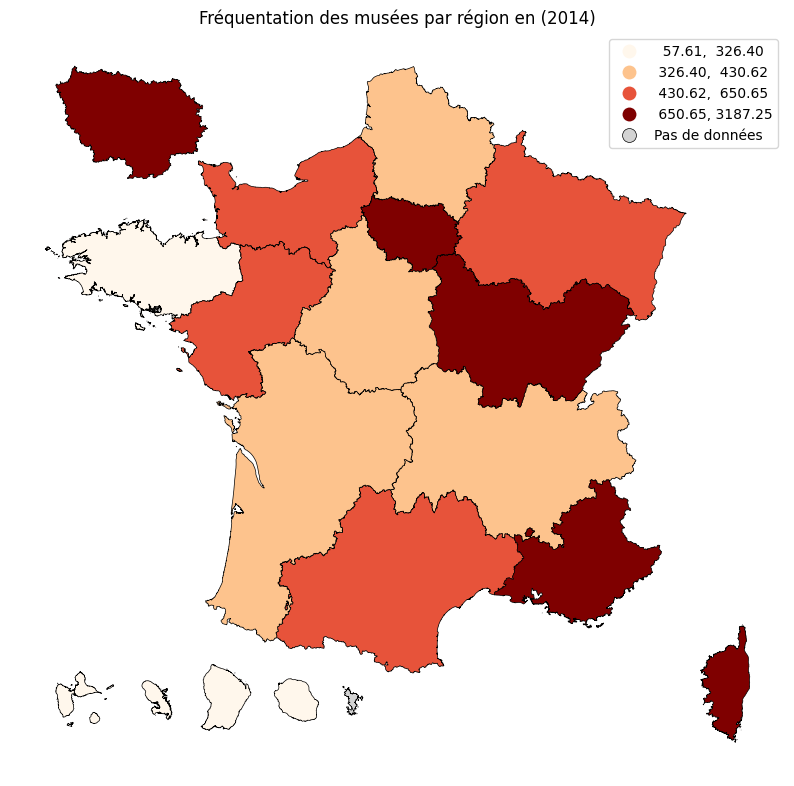

In [31]:
from fonctions import carto_frequentation_region

carte_2022 = carto_frequentation_region(df_freq_totale, "2014", col_freq="freq_pour_1000_hab")

In [32]:
freq_region_annee = (
    df_freq_totale
    .groupby(["annee", "NOMREG"], as_index=False)["freq_pour_1000_hab"]
    .sum()
)

freq_region_annee.loc[
    freq_region_annee["freq_pour_1000_hab"] > 1000,
    ["annee", "NOMREG", "freq_pour_1000_hab"]
].sort_values(["NOMREG", "annee"])

,annee,NOMREG,freq_pour_1000_hab
17,2001,ÎLE-DE-France,1672.452286
35,2002,ÎLE-DE-France,1808.144484
53,2003,ÎLE-DE-France,1805.578949
71,2004,ÎLE-DE-France,2028.775180
89,2005,ÎLE-DE-France,2117.515654
107,2006,ÎLE-DE-France,2517.444419
125,2007,ÎLE-DE-France,2635.561368
143,2008,ÎLE-DE-France,2805.628838
161,2009,ÎLE-DE-France,2814.197818
179,2010,ÎLE-DE-France,2838.559289
